In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
df=pd.read_csv("spam.csv",encoding="latin-1")
print(df.head())
print(df.shape)
print(df.columns)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [4]:
df=df[["v1","v2"]]
df.columns=["label","message"]
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
print(df.shape)


(5572, 2)


In [6]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [8]:
df=df.dropna()

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["label"]=df["label"].map({
    "ham":0,
    "spam":1
})
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
x=df["message"]
y=df["label"]
print(x.head())
print(y.head())

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: str
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [14]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y)
print(len(x_train))
print(len(x_test))

4135
1034


In [15]:
vectorizer=TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)
x_train_tfidf=vectorizer.fit_transform(x_train)
x_test_tfidf=vectorizer.transform(x_test)
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(4135, 7329)
(1034, 7329)


In [16]:
model=MultinomialNB()
model.fit(x_train_tfidf,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [17]:
y_pred = model.predict(x_test_tfidf)

print(y_pred[:25])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [18]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9661508704061895


In [19]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[902   1]
 [ 34  97]]


In [20]:
cr=classification_report(y_test,y_pred,target_names=["ham","spam"])
print(cr)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [21]:
always_ham=np.zeros(len(y_test))
baseline_accuracy=accuracy_score(
    y_test,
    always_ham
)
print(baseline_accuracy)
print(accuracy)


0.8733075435203095
0.9661508704061895


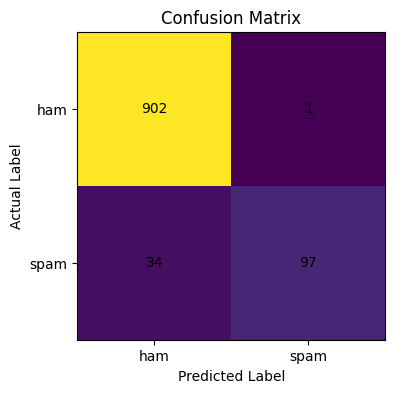

In [22]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1],["ham","spam"])

plt.yticks([0,1],["ham","spam"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.show()

In [23]:
my_messages=[
    "Congratulations! You won a free iPhone. Claim now!",
    "Hey, are you coming to college today?",
    "URGENT! You have won 50000 dollars. Call now!",
    "Can you send me the assignment?",
    "Get a free reward by clicking this link"
]
    

In [24]:
my_msg_tfidf=vectorizer.transform(my_messages)
prediction=model.predict(my_msg_tfidf)


In [25]:
for message, prediction in zip(my_messages, prediction):
    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"
    
    print(message)
    print("Prediction:", result)
    print()

Congratulations! You won a free iPhone. Claim now!
Prediction: SPAM

Hey, are you coming to college today?
Prediction: HAM

URGENT! You have won 50000 dollars. Call now!
Prediction: HAM

Can you send me the assignment?
Prediction: HAM

Get a free reward by clicking this link
Prediction: HAM



In [26]:
import pickle

# Save trained model
with open("spam_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save TF-IDF vectorizer
with open("vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
